# Pairing model diagnostics

The pairing model (`docs/fff_pairing.md`, `src/ff/pairing/`) against the film model and the
Q-Chem scans of `qchem_roundtrip/pairing_scans`. All code lives in `notebooks/pairing_plots.py`
(autoreloaded); this notebook sets the knobs and draws the figures.

**What is compared.** Both models are evaluated on exactly the frames Q-Chem labeled:
rigid O-H stretches of H2O / H3O+ / OH-, an H-O-H bend, and the shared proton of H5O2+ /
H3O2- walking between the oxygens at four O-O distances. The one-body energy is pulled apart
into what each model is made of -- Morse + angle + gated intra classical for the film,
`E_pair + Pauli wall` for the pairing model -- and the bond orders are drawn along the scans.

**Models.** `PAIRING_CHECKPOINT = None` builds the pairing model at its priors (no fit: the
calibrated functional alone, worth seeing on its own). `FILM_CHECKPOINT` is a film committee
member; note the water committee has never seen an ion, so its curves on H3O+ / OH- / the
proton scans are extrapolation and carry a large constant offset (reported in the legends).

**A caveat on the labels.** The scan template is restricted (RKS), so beyond ~1.8 Å the
stretches climb toward the closed-shell ionic limit rather than the homolytic OH + H one:
the reference is only physical inside ~1.8 Å; both models plateau at the homolytic well
depth, which is the right answer to a different question. Rerun the stretches unrestricted
(`UNRESTRICTED = true`, `SCF_GUESS_MIX`) before reading anything past that.

In [11]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks"))

import pairing_plots as pp


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# ---- Knobs ---------------------------------------------------------------------------------
#: A pairing checkpoint (`film.model: pairing`), or None for the model at its priors.
PAIRING_CHECKPOINT = None
#: A film checkpoint for the Morse + angle comparison (one committee member's best.pt).
FILM_CHECKPOINT = "qchem_roundtrip/train/runs/film_committee_100k/member_00/member_00_full/best.pt"
#: Frames of each monomer AIMD set used for the fragment-energy parity.
MONOMER_FRAMES = 200


In [13]:
scans = pp.load_scans()

if PAIRING_CHECKPOINT:
    pairing, pairing_cfg = pp.load_model(str(ROOT / PAIRING_CHECKPOINT))
    pairing_label = "pairing"
else:
    pairing, pairing_cfg = pp.build_prior_pairing_model()
    pairing_label = "pairing (priors)"
film, film_cfg = pp.load_model(str(ROOT / FILM_CHECKPOINT))
models = {pairing_label: pairing, "film": film}

results = pp.evaluate_all(models, scans)
{name: sorted(res) for name, res in results.items()}


{'h2o_stretch': ['film', 'pairing (priors)'],
 'h3o+_stretch': ['film', 'pairing (priors)'],
 'oh-_stretch': ['film', 'pairing (priors)'],
 'h2o_bend': ['film', 'pairing (priors)'],
 'h5o2+_pt': ['film:A', 'film:B', 'pairing (priors)'],
 'h3o2-_pt': ['film:A', 'film:B', 'pairing (priors)']}

## The O-H stretches

Left: the curves against Q-Chem, referenced to the Q-Chem minimum. Middle: model minus
Q-Chem with the mean removed -- a kink in the film's curve is the range-separation switch
turning the intramolecular classical terms on; the pairing curve has nothing to switch.
Right: what the one-body energy is made of. For the pairing model the two pieces are the
pairing functional (attractive, `-J p + kappa p^2/2 + barriers`) and the Pauli wall (`c E_pauli`);
for the film they are Morse + angle and the gated intra classical sum.

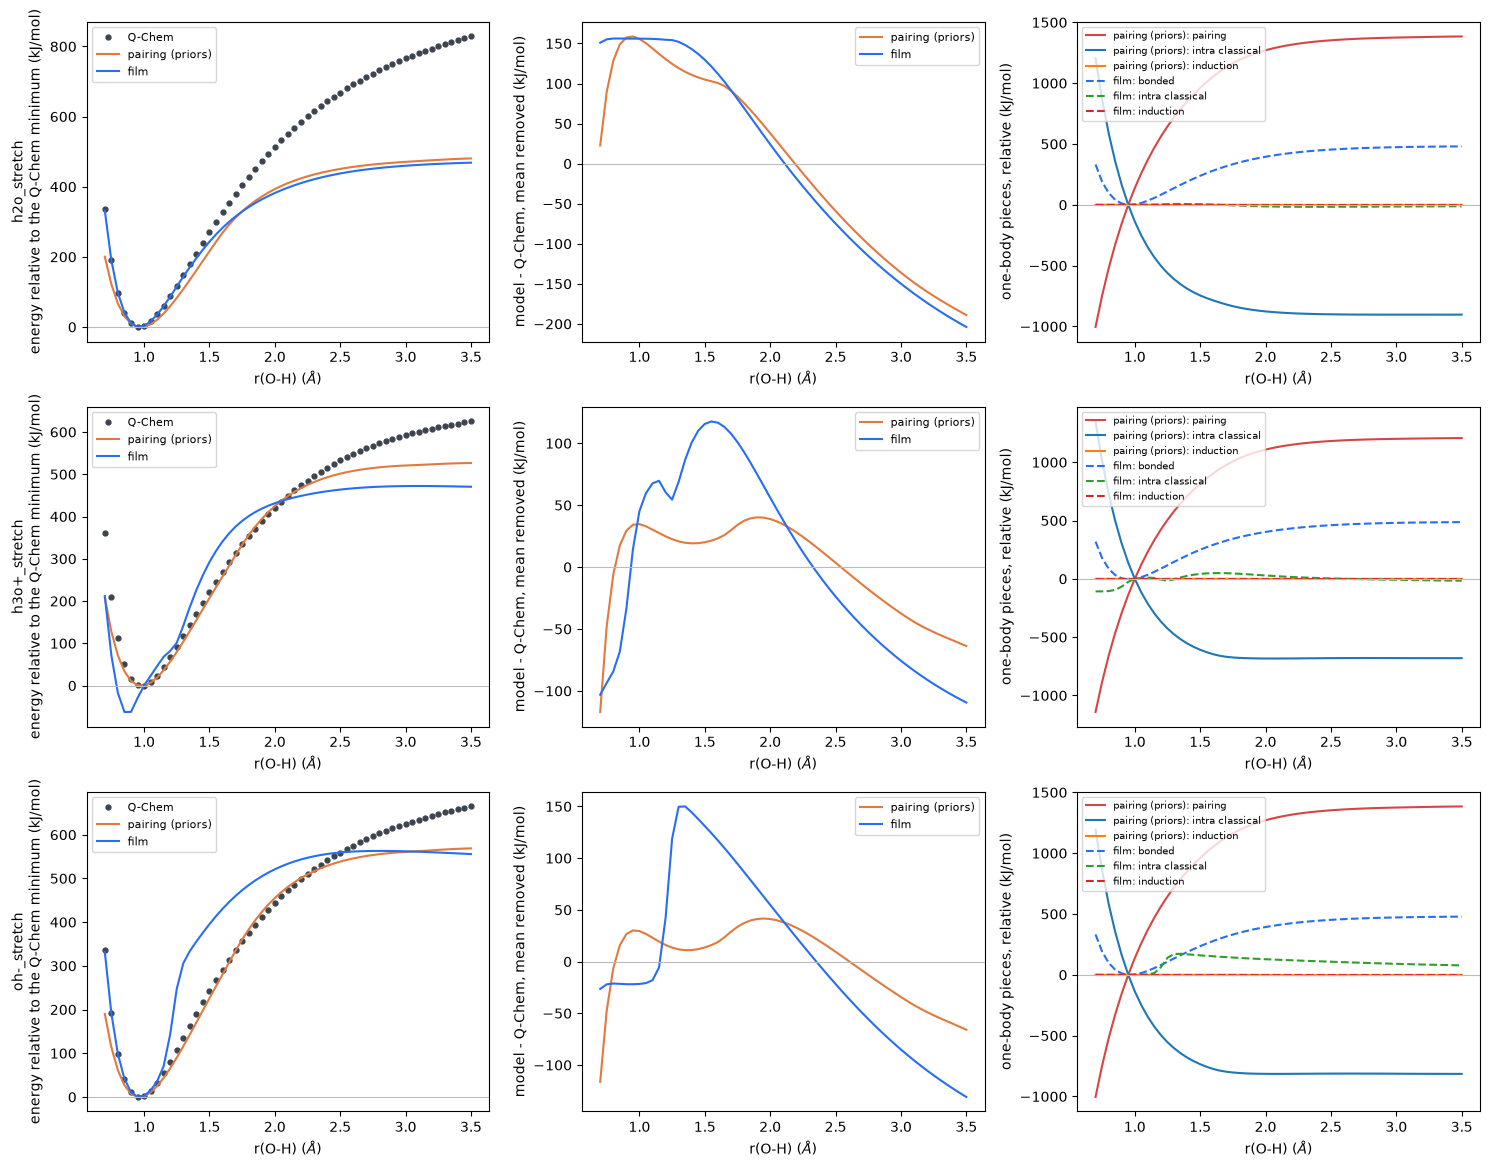

In [14]:
pp.plot_stretches(scans, results, path="stretches");

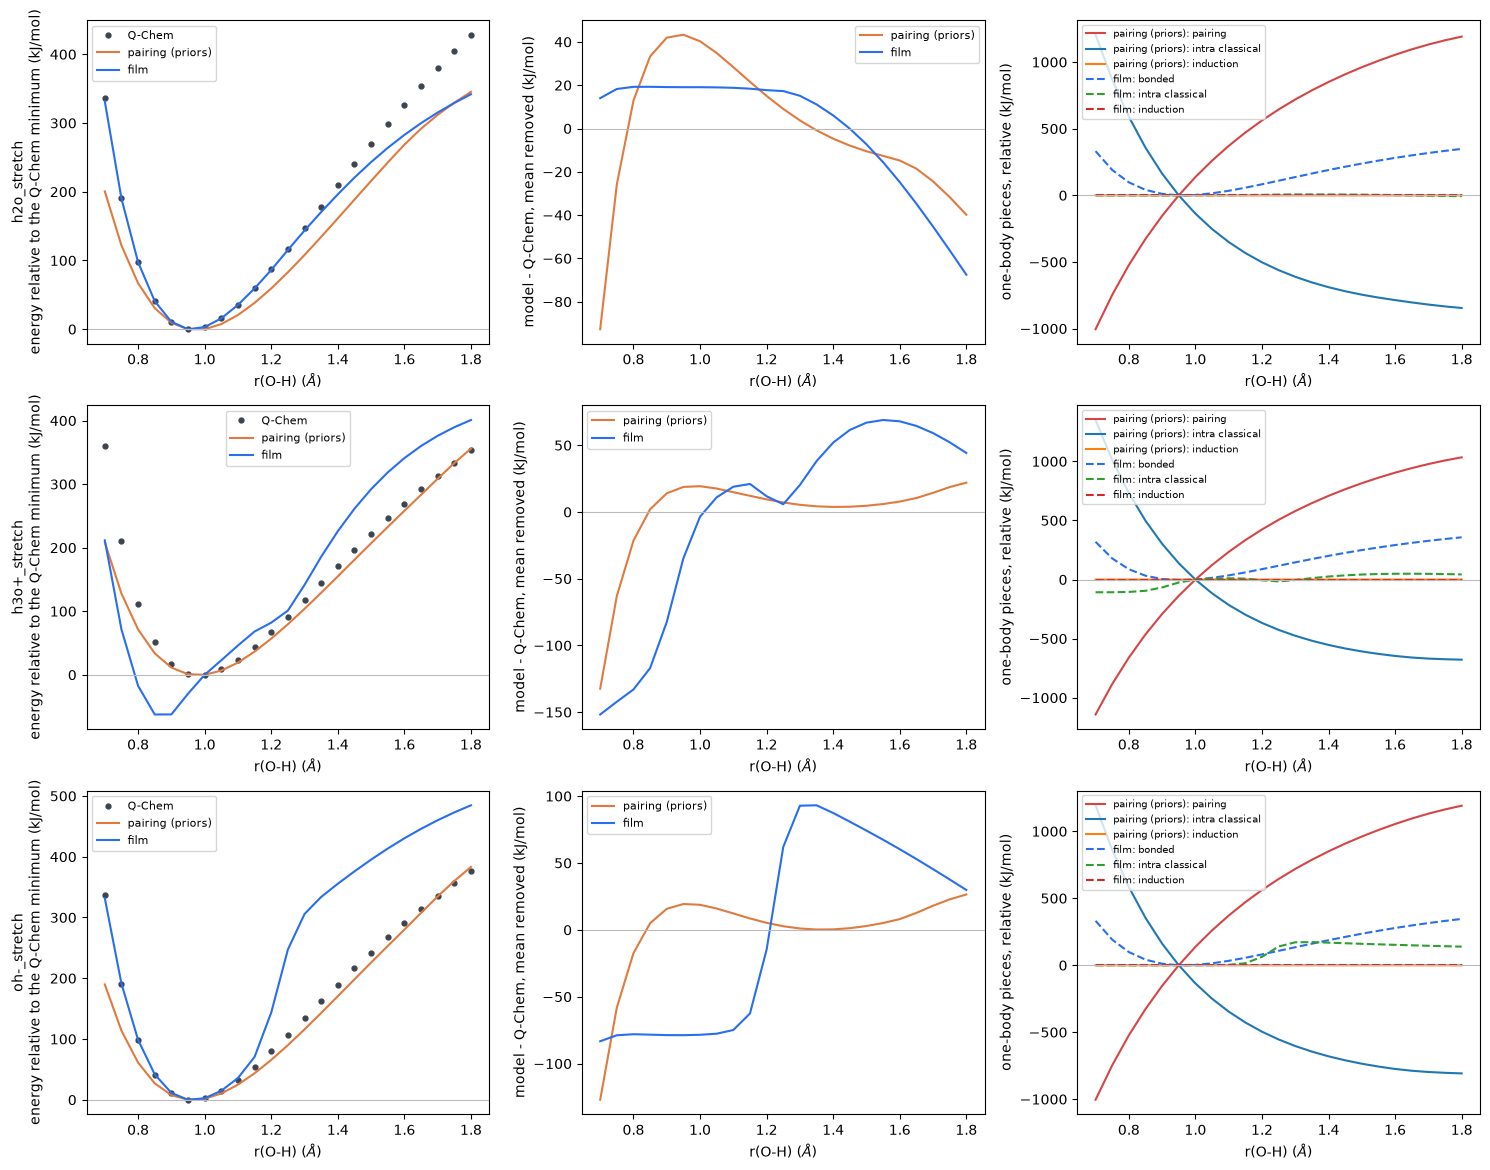

In [15]:
# the same, inside the range the RKS labels are physical
pp.plot_stretches(scans, results, x_max=1.8, path="stretches_zoom");

## The bend

The pairing model has no angle term: bending resistance comes from the 1-3 H-H Pauli wall
and from the quadrupolar part of the valence density (zero at the priors, so at the priors
the bend is Pauli alone and too soft).

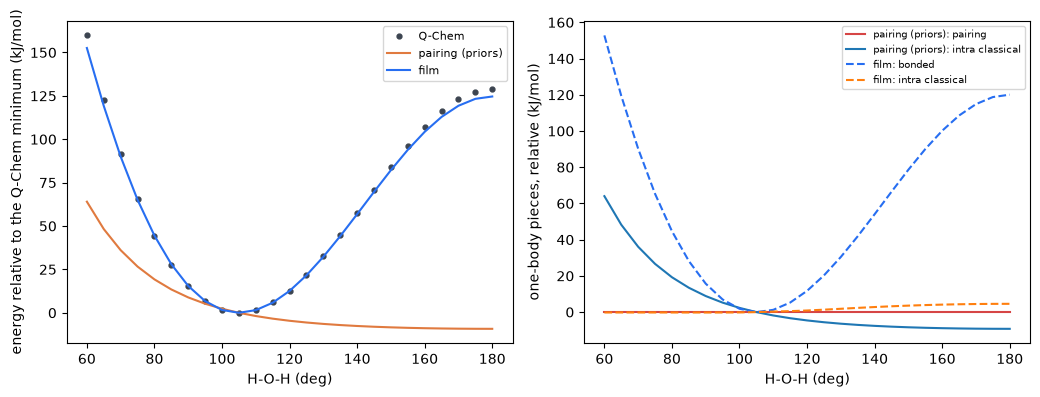

In [16]:
pp.plot_bend(scans, results, path="bend");

## The shared proton

Each curve is referenced to its own midpoint, so the panels compare shapes: Q-Chem's double
well opening up as O-O grows, the pairing model's single curve, and the film's two diabats
(proton assigned to either oxygen), which cross at the midpoint. The legend carries each
model's absolute offset from Q-Chem at the midpoint.

At the priors the pairing model cannot localize the proton: the fragment's charge is split
2.5 / 2.5 over the two oxygens, so the shared proton is 0.5 / 0.5 wherever it sits, and the
curve is a single stiff well. That is the fragment-level valence prior, not the functional --
the learned valence scale, and later the electron-count valence, are what let it move.

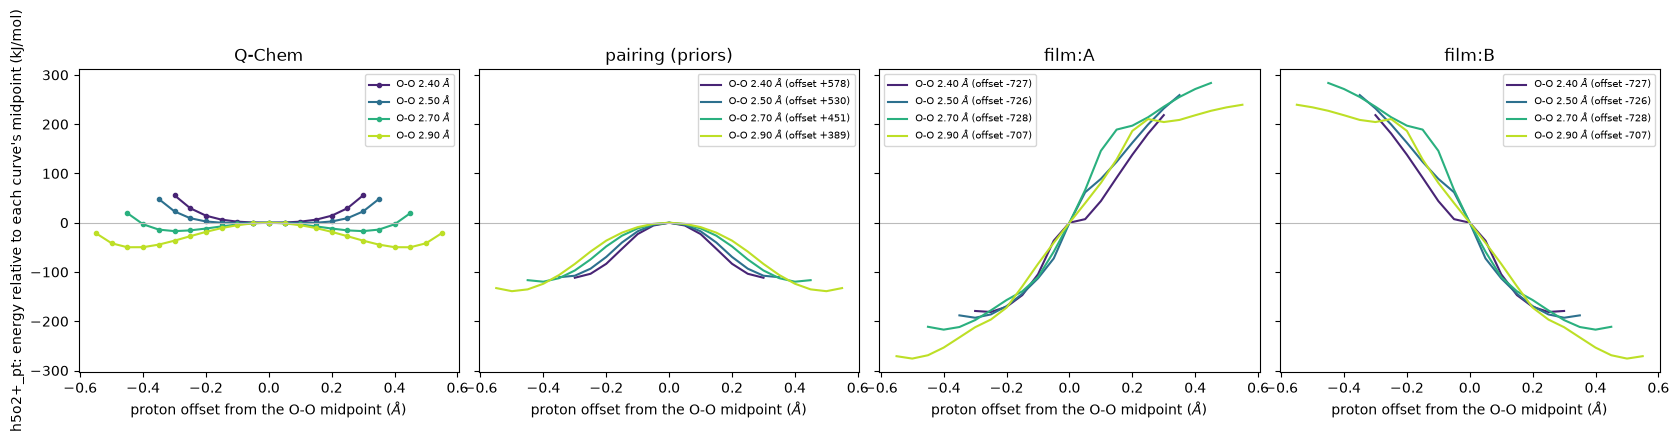

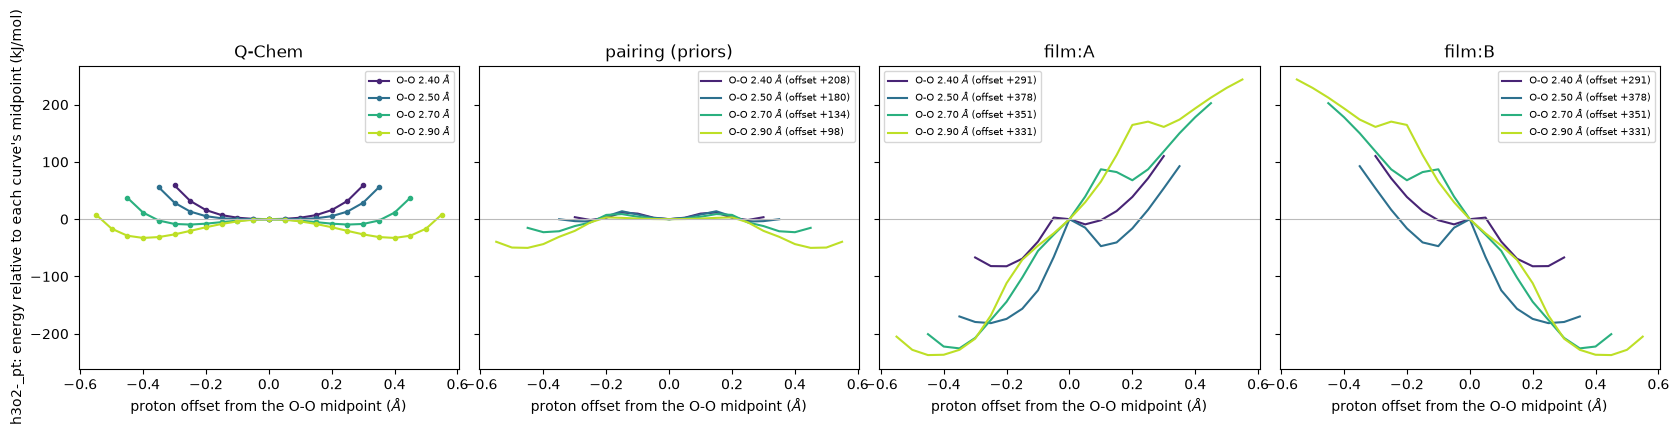

In [17]:
pp.plot_proton_transfer(scans, results, "h5o2+_pt", path="h5o2+_pt");
pp.plot_proton_transfer(scans, results, "h3o2-_pt", path="h3o2-_pt");

## Bond orders along the scans

`p` is the solved bond order of the watched pair, `c` its co-membership (what the classical
channels see), and the dash-dotted line the total unpaired valence of the frame. Where `p`
lets go is where the intramolecular electrostatics and dispersion turn on.

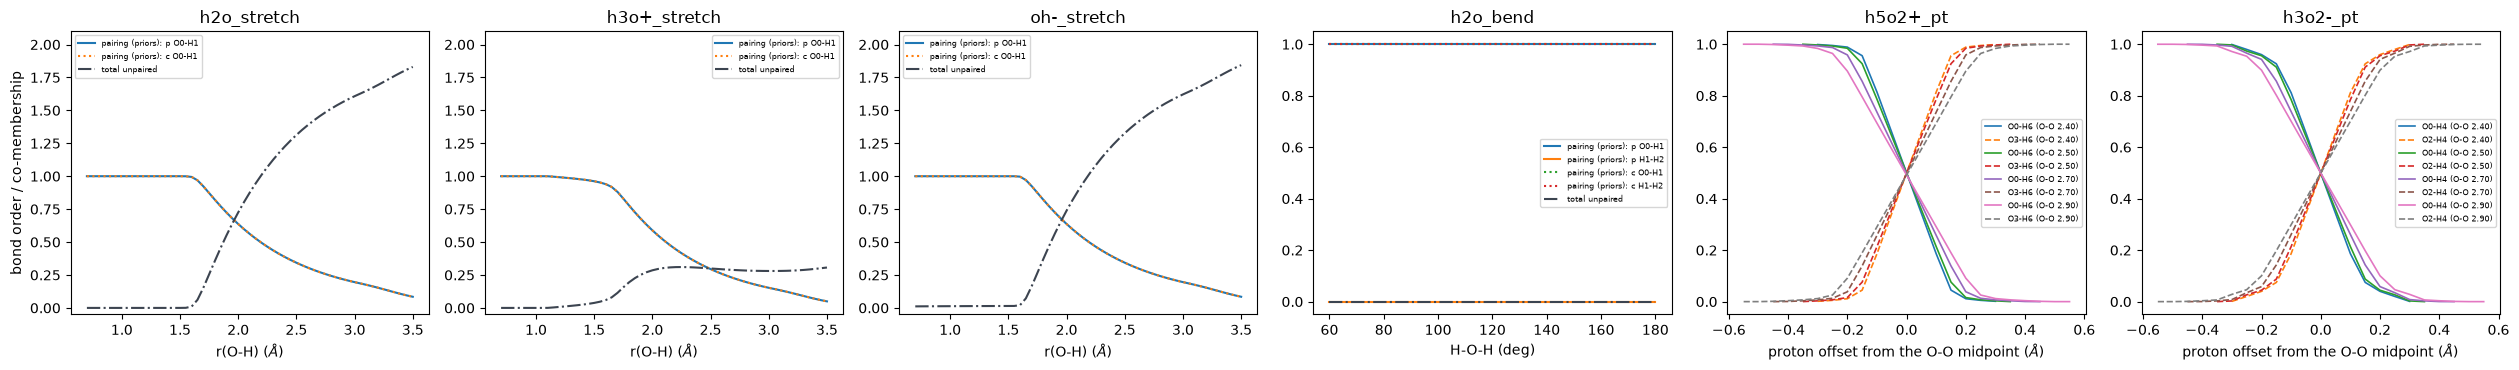

In [18]:
pp.plot_bond_orders(scans, results, path="bond_orders");

## Formal charges along the scans

`q^f` from the joint bond-order / formal-count solve (`docs/fff_pairing.md` §2.4): the Lewis
charge, not the SQE partial charge. Water should stretch homolytically (no charge, two unpaired
electrons), hydronium heterolytically (the leaving hydrogen takes the +1), and the shared proton
should hand the charge from one oxygen to the other.

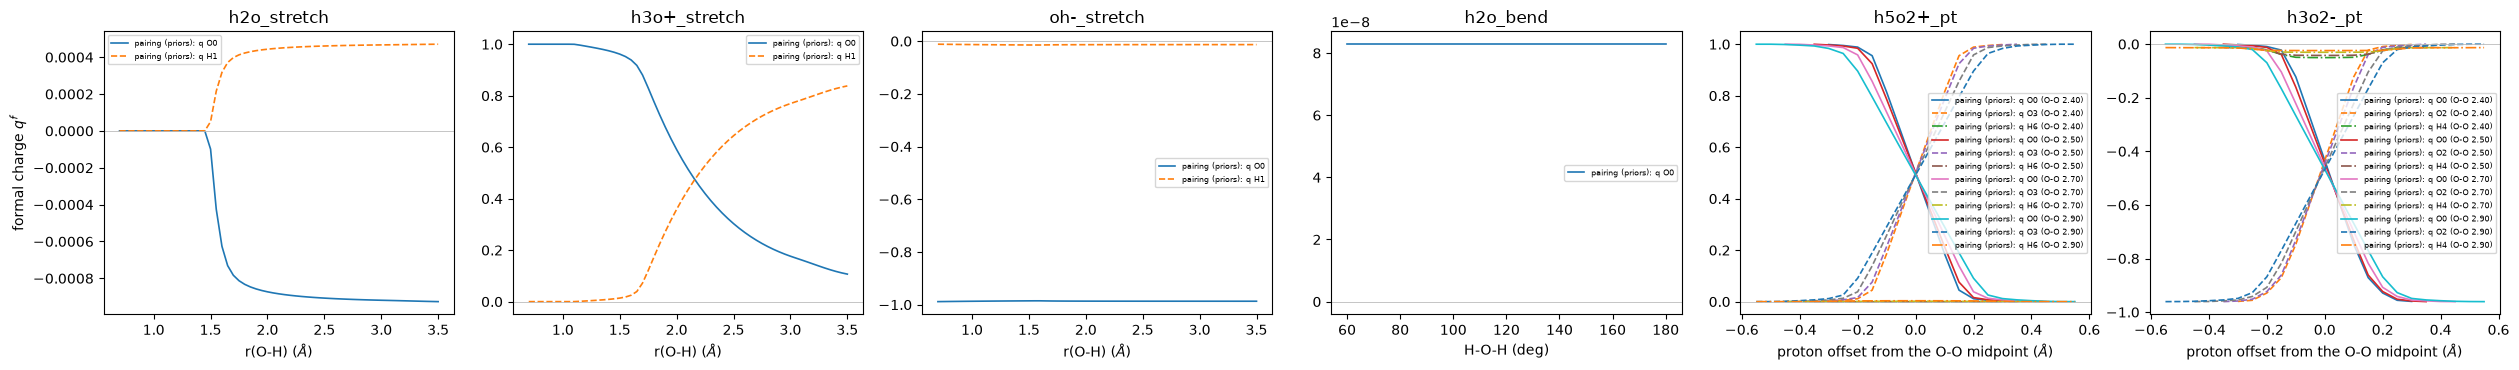

In [19]:
pp.plot_formal_charges(scans, results, path="formal_charges");

## The monomer AIMD sets

Fragment-energy parity on the thermal monomer frames (the film's one-body training data).
Bias is removed per model and quoted; at the priors the pairing model's bias is the
calibration error of the well depth, its MAE the shape error.

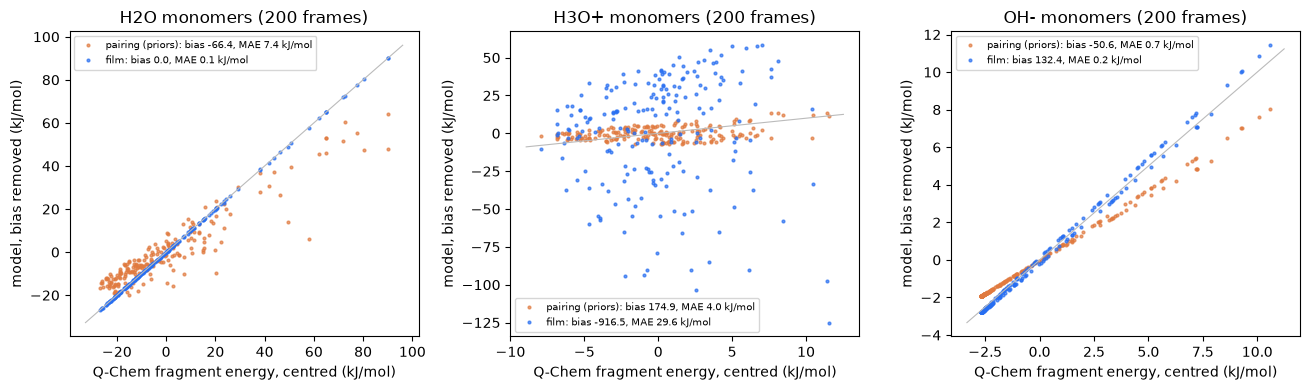

In [20]:
parity = pp.monomer_parity(models, n_frames=MONOMER_FRAMES)
pp.plot_monomer_parity(parity, path="monomer_parity");